In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using Device:{device}")

Using Device:cuda


In [3]:
df = pd.read_csv("fashion-mnist_train.csv")

In [4]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,9,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,6,0,0,0,0,0,0,0,5,0,...,0.0,0.0,0.0,30.0,43.0,0.0,0.0,0.0,0.0,0.0
3,0,0,0,0,1,2,0,0,0,0,...,3.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,3,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
df.shape

(9000, 785)

In [6]:
X = df.iloc[:,1:].values
y = df.iloc[:,0].values

In [7]:
import numpy as np
X = np.nan_to_num(X,nan=0.0)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [9]:
# performing the scailing
X_train = X_train/255.0
X_test = X_test/255.0

In [10]:
# Create a CustomDataset class
class CustomDataset(Dataset):

  def __init__(self, features, labels):

    self.features = torch.tensor(features, dtype=torch.float32).reshape(-1,1,28,28)
    self.labels = torch.tensor(labels, dtype=torch.long)

  def __len__(self):

    return len(self.features)

  def __getitem__(self,index):

    return self.features[index], self.labels[index]

In [11]:
# create train_dataset object
train_dataset = CustomDataset(X_train, y_train)

In [12]:
test_dataset = CustomDataset(X_test,y_test)

In [13]:
# create train and test loader object
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True) # pin_memory is simply used to speed up the training on GPU
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True) # while predicting, you usually dont wanna shuffle the data.

Our architecture

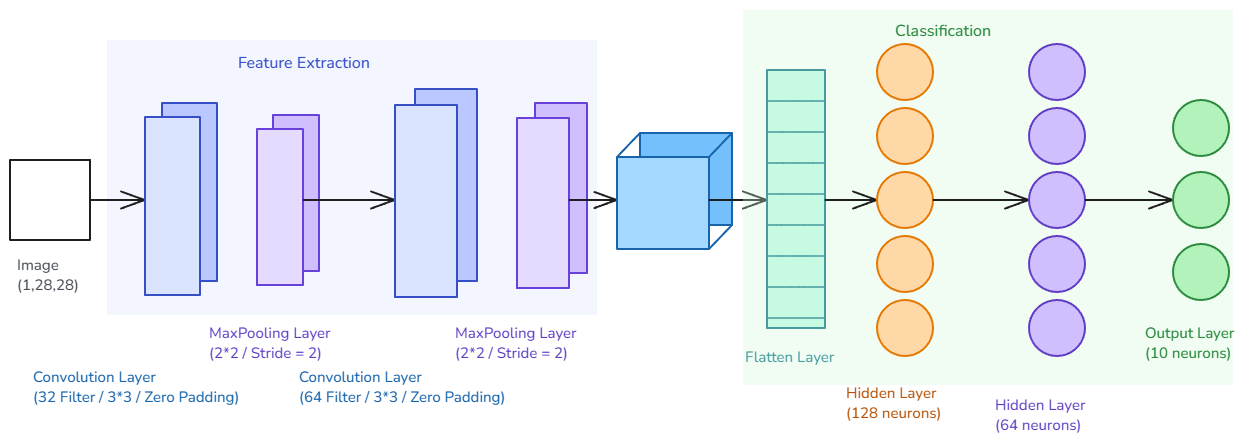

In [19]:
# Define a NN class
class vrajNN(nn.Module):

  def __init__(self, input_features):

    super().__init__() # invoking the parent constructor

    self.features = nn.Sequential(
        nn.Conv2d(input_features, 32, kernel_size=3, padding='same'),
        nn.ReLU(),
        nn.BatchNorm2d(32),
        nn.MaxPool2d(kernel_size=2, stride=2),

        nn.Conv2d(32, 64, kernel_size=3, padding='same'),
        nn.ReLU(),
        nn.BatchNorm2d(64),
        nn.MaxPool2d(kernel_size=2, stride=2),
    )

    self.classifier = nn.Sequential(
        nn.Flatten(), # this value is defined by the shape of the tensor in last layer. shape was 64*7*7
        nn.Linear(64*7*7, 128),
        nn.ReLU(),
        nn.Dropout(p=0.2),

        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Dropout(p=0.2),

        nn.Linear(64,10)
    )

  def forward(self, x):
    x = self.features(x)
    x = self.classifier(x)

    return x

In [20]:
# setting learning rate and epochs
epochs = 100
learning_rate = 0.1

In [21]:
# instantiate the model
model = vrajNN(1)
model.to(device)
# loss function
criterion = nn.CrossEntropyLoss()
# Optimizer
optimizer = optim.SGD(model.parameters(), lr=learning_rate, weight_decay=1e-4)

In [22]:
# training loop
for epoch in range(epochs):

  total_epoch_loss = 0 # setting up a variable in order to track the loss across each epoch

  for batch_features, batch_labels in train_loader:

    # move data to GPU
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    # forward pass
    outputs = model(batch_features)

    # loss calculate
    loss = criterion(outputs, batch_labels)

    # back propagation
    optimizer.zero_grad() # clearing out gradients
    loss.backward()

    # update weights
    optimizer.step()

    total_epoch_loss = total_epoch_loss + loss.item()

  avg_loss = total_epoch_loss / len(train_loader)
  print(f'Epoch: {epoch+1}, Loss : {avg_loss}')

Epoch: 1, Loss : 0.7641536821259393
Epoch: 2, Loss : 0.4741083490848541
Epoch: 3, Loss : 0.3892083038886388
Epoch: 4, Loss : 0.329733012980885
Epoch: 5, Loss : 0.29482720928059686
Epoch: 6, Loss : 0.26313269509209525
Epoch: 7, Loss : 0.24079996950924396
Epoch: 8, Loss : 0.21147332141796749
Epoch: 9, Loss : 0.19980937767359946
Epoch: 10, Loss : 0.1816236062430673
Epoch: 11, Loss : 0.15509078160963125
Epoch: 12, Loss : 0.1428030793575777
Epoch: 13, Loss : 0.12766970682061382
Epoch: 14, Loss : 0.11786943398416043
Epoch: 15, Loss : 0.11350369553288651
Epoch: 16, Loss : 0.11178845995002323
Epoch: 17, Loss : 0.07915998072208216
Epoch: 18, Loss : 0.07766386449466356
Epoch: 19, Loss : 0.06367099758360484
Epoch: 20, Loss : 0.07853869150418581
Epoch: 21, Loss : 0.05685019012459735
Epoch: 22, Loss : 0.057222169562398145
Epoch: 23, Loss : 0.0562175551997239
Epoch: 24, Loss : 0.04668014492309238
Epoch: 25, Loss : 0.04593791658375671
Epoch: 26, Loss : 0.05545406611843241
Epoch: 27, Loss : 0.03443509

In [23]:
# set model to the evaluation mode
model.eval() # we have to explicitly tell the model that it's in eval mode because sometimes, some models might behave different while training and testing. for ex, dropouts.

vrajNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (5): ReLU()
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.2, inplace=False)
    (7): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [25]:
# Evaluation code
total = 0
correct = 0

with torch.no_grad():
    for batch_features, batch_labels in test_loader:
      # move data to GPU
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        outputs = model(batch_features)

        _, predicted = torch.max(outputs, 1)  # Calculates class with max probability

        total += batch_labels.shape[0]      # Accumulate total samples

        correct += (predicted == batch_labels).sum().item()  # Count correct predictions

print(f"Accuracy: {correct / total:.4f}")  # or just correct/total

Accuracy: 0.8900
